# Timings run on an NVIDIA A100 GPU
Using SURF Snellius Jupyter notebooks

In [1]:
!nvidia-smi

Thu Jun 19 15:21:01 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:31:00.0 Off |                    0 |
| N/A   29C    P0             48W /  400W |       1MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# You will need to restart the session after running this cell
!pip install --upgrade pip --quiet
!pip install pytorch_nd_semiconv ninja tqdm seaborn --quiet

!git clone https://github.com/thierry123454/parabolic_pooling_investigation --quiet 2>/dev/null || true

with open("parabolic_pooling_investigation/morphology_package/setup.py") as f:
    setup = f.read()

with open("parabolic_pooling_investigation/morphology_package/setup.py", "w") as f:
    f.write(setup.replace("torch==1.11.0", "torch>=2"))

%env CUDA_HOME=/sw/arch/RHEL9/EB_production/2024/software/CUDA/12.6.0
!cd parabolic_pooling_investigation/morphology_package/ && python setup.py install --user --quiet

In [3]:
import gc
import math
import timeit

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from pytorch_nd_semiconv import SelectSemifield, BroadcastSemifield
from tqdm.auto import trange

In [4]:
%matplotlib inline
sns.set_theme("paper", "whitegrid")
plt.rc("figure", dpi=500)

In [5]:
torch.manual_seed(0)
data_32x32 = torch.randn((60000, 6, 32, 32), device="cuda")
print(data_32x32.nbytes, "bytes")
data_32x32.shape

1474560000 bytes


torch.Size([60000, 6, 32, 32])

In [6]:
torch.manual_seed(0)
kernels_3x3 = -torch.rand((6, 1, 3, 3), device="cuda")
kernels_3x3.shape

torch.Size([6, 1, 3, 3])

In [7]:
unfold_dilate_copy = BroadcastSemifield.tropical_max().dynamic(unfold_copy=True)
unfold_dilate = BroadcastSemifield.tropical_max().dynamic()
unfold_dilate_spread = BroadcastSemifield.tropical_max(spread_gradient=True).dynamic()

In [8]:
select_dilate_ext = SelectSemifield.tropical_max().dynamic(to_extension=True)
select_dilate_py = SelectSemifield.tropical_max().dynamic(to_extension=False)

In [9]:
try:
    import morphological_torch

    # noinspection PyUnusedLocal
    def rick_dilate(
        imgs, kernel, padding=None, stride=2, dilation=None, groups=None, kind=None
    ):
        return morphological_torch.pooling_autograd.ParameterizedMaxPool2DAutogradFunction.apply(
            imgs, kernel.squeeze(1), stride, 0
        )[0]

    print("Morphpool loaded")
except ImportError:
    rick_dilate = None
    print("Morphpool not loaded")

Morphpool loaded


In [10]:
test_results = []
test_grads_img = []
test_grads_kernel = []
for test_op in (
    unfold_dilate,
    unfold_dilate_copy,
    SelectSemifield.tropical_max().lazy_fixed(),
    rick_dilate,
):
    if not test_op:
        continue

    test_di = data_32x32[:4096].clone().requires_grad_(True)
    test_dk = kernels_3x3.clone().requires_grad_(True)
    test_res = test_op(test_di, test_dk, stride=1, padding=1, groups=6, kind="corr")
    test_results.append(test_res.clone().detach())
    test_res.sum().backward()
    test_grads_img.append(test_di.grad.clone())
    test_grads_kernel.append(test_dk.grad.clone())

In [11]:
import itertools

for i0, i1 in itertools.product(range(len(test_results)), repeat=2):
    torch.allclose(test_results[i0], test_results[i1])
    torch.allclose(test_grads_img[i0], test_grads_img[i1])
    torch.allclose(test_grads_kernel[i0], test_grads_kernel[i1])

In [12]:
def maxpool_nodilate(
    imgs, kernel, padding="same", stride=2, dilation=1, groups=None, kind=None
):
    if padding == "same":
        padding = kernel.shape[2] // 2
    return torch.nn.functional.max_pool2d(
        imgs, kernel.shape[2:], stride=stride, padding=padding, dilation=dilation
    )

In [13]:
def time_conv(
    conv,
    imgs: torch.Tensor,
    kernels: torch.Tensor,
    target_time: float = 1.0,
    cudagraphs: bool = True,
    **kwargs,
):
    imgs, kernels = imgs.cuda(), kernels.cuda()
    assert imgs.requires_grad and kernels.requires_grad

    gc.collect()
    torch.cuda.empty_cache()

    if cudagraphs:
        conv(imgs, kernels, **kwargs)
        # noinspection PyProtectedMember
        torch._dynamo.reset()
        torch.compiler.cudagraph_mark_step_begin()
        conv = torch.compile(conv, mode="reduce-overhead", fullgraph=True)

    gradient = torch.randn_like(conv(imgs, kernels, **kwargs))

    def run():
        res = conv(imgs, kernels, **kwargs)
        res.backward(gradient)
        torch.cuda.synchronize()

    run()

    timer = timeit.Timer("run()", globals={"run": run})
    timer.timeit(1)

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    mem_start = torch.cuda.memory_stats()["allocated_bytes.all.peak"]
    run()
    mem_end = torch.cuda.memory_stats()["allocated_bytes.all.peak"]

    autorange_runs, autorange_time = timer.autorange()
    target_runs = math.ceil(autorange_runs / autorange_time * target_time / 2)
    if target_runs < 10:
        print(f"warning: {conv} slow, {target_runs = }")

    # Run it twice to reduce the effects of interference
    return min(timer.repeat(2, target_runs)) / target_runs, mem_end - mem_start

In [14]:
for test_op in (
    select_dilate_py,
    select_dilate_ext,
    maxpool_nodilate,
    unfold_dilate,
    unfold_dilate_copy,
):
    _time, _mem = time_conv(
        test_op,
        data_32x32[:32].clone().requires_grad_(True),
        kernels_3x3.clone().requires_grad_(True),
        cudagraphs=False,
        groups=6,
        stride=3,
    )
    print(round(_time, 7), "s | ", _mem / 1e6, "MB")

0.0014838 s |  0.944128 MB
0.0004029 s |  0.944128 MB
0.0001124 s |  1.065472 MB
0.0005338 s |  2.399744 MB
0.0006936 s |  3.186176 MB


In [15]:
def get_timings_comparison(
    data: torch.Tensor = data_32x32,
    kernel: torch.Tensor = kernels_3x3,
    stop: int = 28,
    groups=6,
    cudagraphs: bool = False,
    padding: str | int | tuple[int, int] = "same",
    **time_kwargs,
):
    kernel = kernel.clone().requires_grad_(True)

    convs = {
        "Unfold view": unfold_dilate,
        "Unfold copy": unfold_dilate_copy,
        "Numba, Array API": select_dilate_py,
        "Numba, C++ extension": select_dilate_ext,
        "Torch MaxPool2D": maxpool_nodilate,
    }
    if not cudagraphs and rick_dilate:
        convs["Morphpool"] = rick_dilate
    timings = {name: [] for name in convs}
    mems = {name: [] for name in convs}
    sizes = []
    assert math.ceil(2 ** (stop / 2)) <= len(data), "Stop too high"

    gc.collect()
    torch.cuda.empty_cache()

    bar = trange(stop - 1, 1, -1)
    for log_size in bar:
        size = math.ceil(2 ** (log_size / 2))
        batch = data[:size].clone().requires_grad_(True)
        sizes.append(batch.nbytes)
        bar.set_postfix(size=len(batch))

        for name, conv in convs.items():
            try:
                torch.cuda.empty_cache()
                time, mem = time_conv(
                    conv,
                    batch,
                    kernel,
                    groups=groups,
                    cudagraphs=cudagraphs,
                    padding=padding,
                    **time_kwargs,
                )
                timings[name].append(time)
                mems[name].append(mem)
            except torch.OutOfMemoryError:
                print(f"OOM on {name}")
                timings[name].append(np.nan)
                mems[name].append(np.nan)

    return sizes, timings, mems

In [ ]:
comp_s1 = get_timings_comparison(stride=1)

In [17]:
def plot_timings_comparison(
    sizes,
    lines: dict[str, list[float]],
    title="",
    xticks: tuple[float, ...] = (2**16, 2**18, 2**20, 2**22, 2**24, 2**26, 2**28),
    xlabels: tuple[str, ...] = (
        "65 KB",
        "262 KB",
        "1 MB",
        "4 MB",
        "17 MB",
        "68 MB",
        "268 MB",
    ),
    mem: bool = False,
):
    fig, ax_large = plt.subplots(
        layout="compressed",
        figsize=(10, 5),
    )
    ax_large: plt.Axes
    basic_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    ax_large.set_ylim((2**16, 2**32) if mem else (10**-5, 10**-1))
    ax_large.set_xscale("log", base=2)
    ax_large.set_yscale("log", base=2 if mem else 10)
    for color, (name, vals) in zip(basic_colors, lines.items()):
        color = "gray" if "MaxPool2D" in name else color
        ax_large.plot(
            sizes,
            vals,
            label=name,
            color=color,
            linestyle="dashed" if "MaxPool2D" in name else None,
        )
        ax_large.scatter(sizes, vals, color=color)

    ax_large.set_xlabel("Batch size (bytes)")
    if mem:
        ax_large.set_ylabel("Peak additional memory usage (bytes)")
        ax_large.set_yticks(
            (2**16, 2**20, 2**24, 2**28, 2**32),
            ("65 KB", "1 MB", "17 MB", "268 MB", "4 GB"),
        )
    else:
        ax_large.set_ylabel("Time (latency in seconds)")

    ax_large.set_xticks(xticks, xlabels)
    fig.suptitle(title)
    ax_large.legend()
    fig.show()

/scratch-local/padema.12497542/ipykernel_3154880/283909195.py:50: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


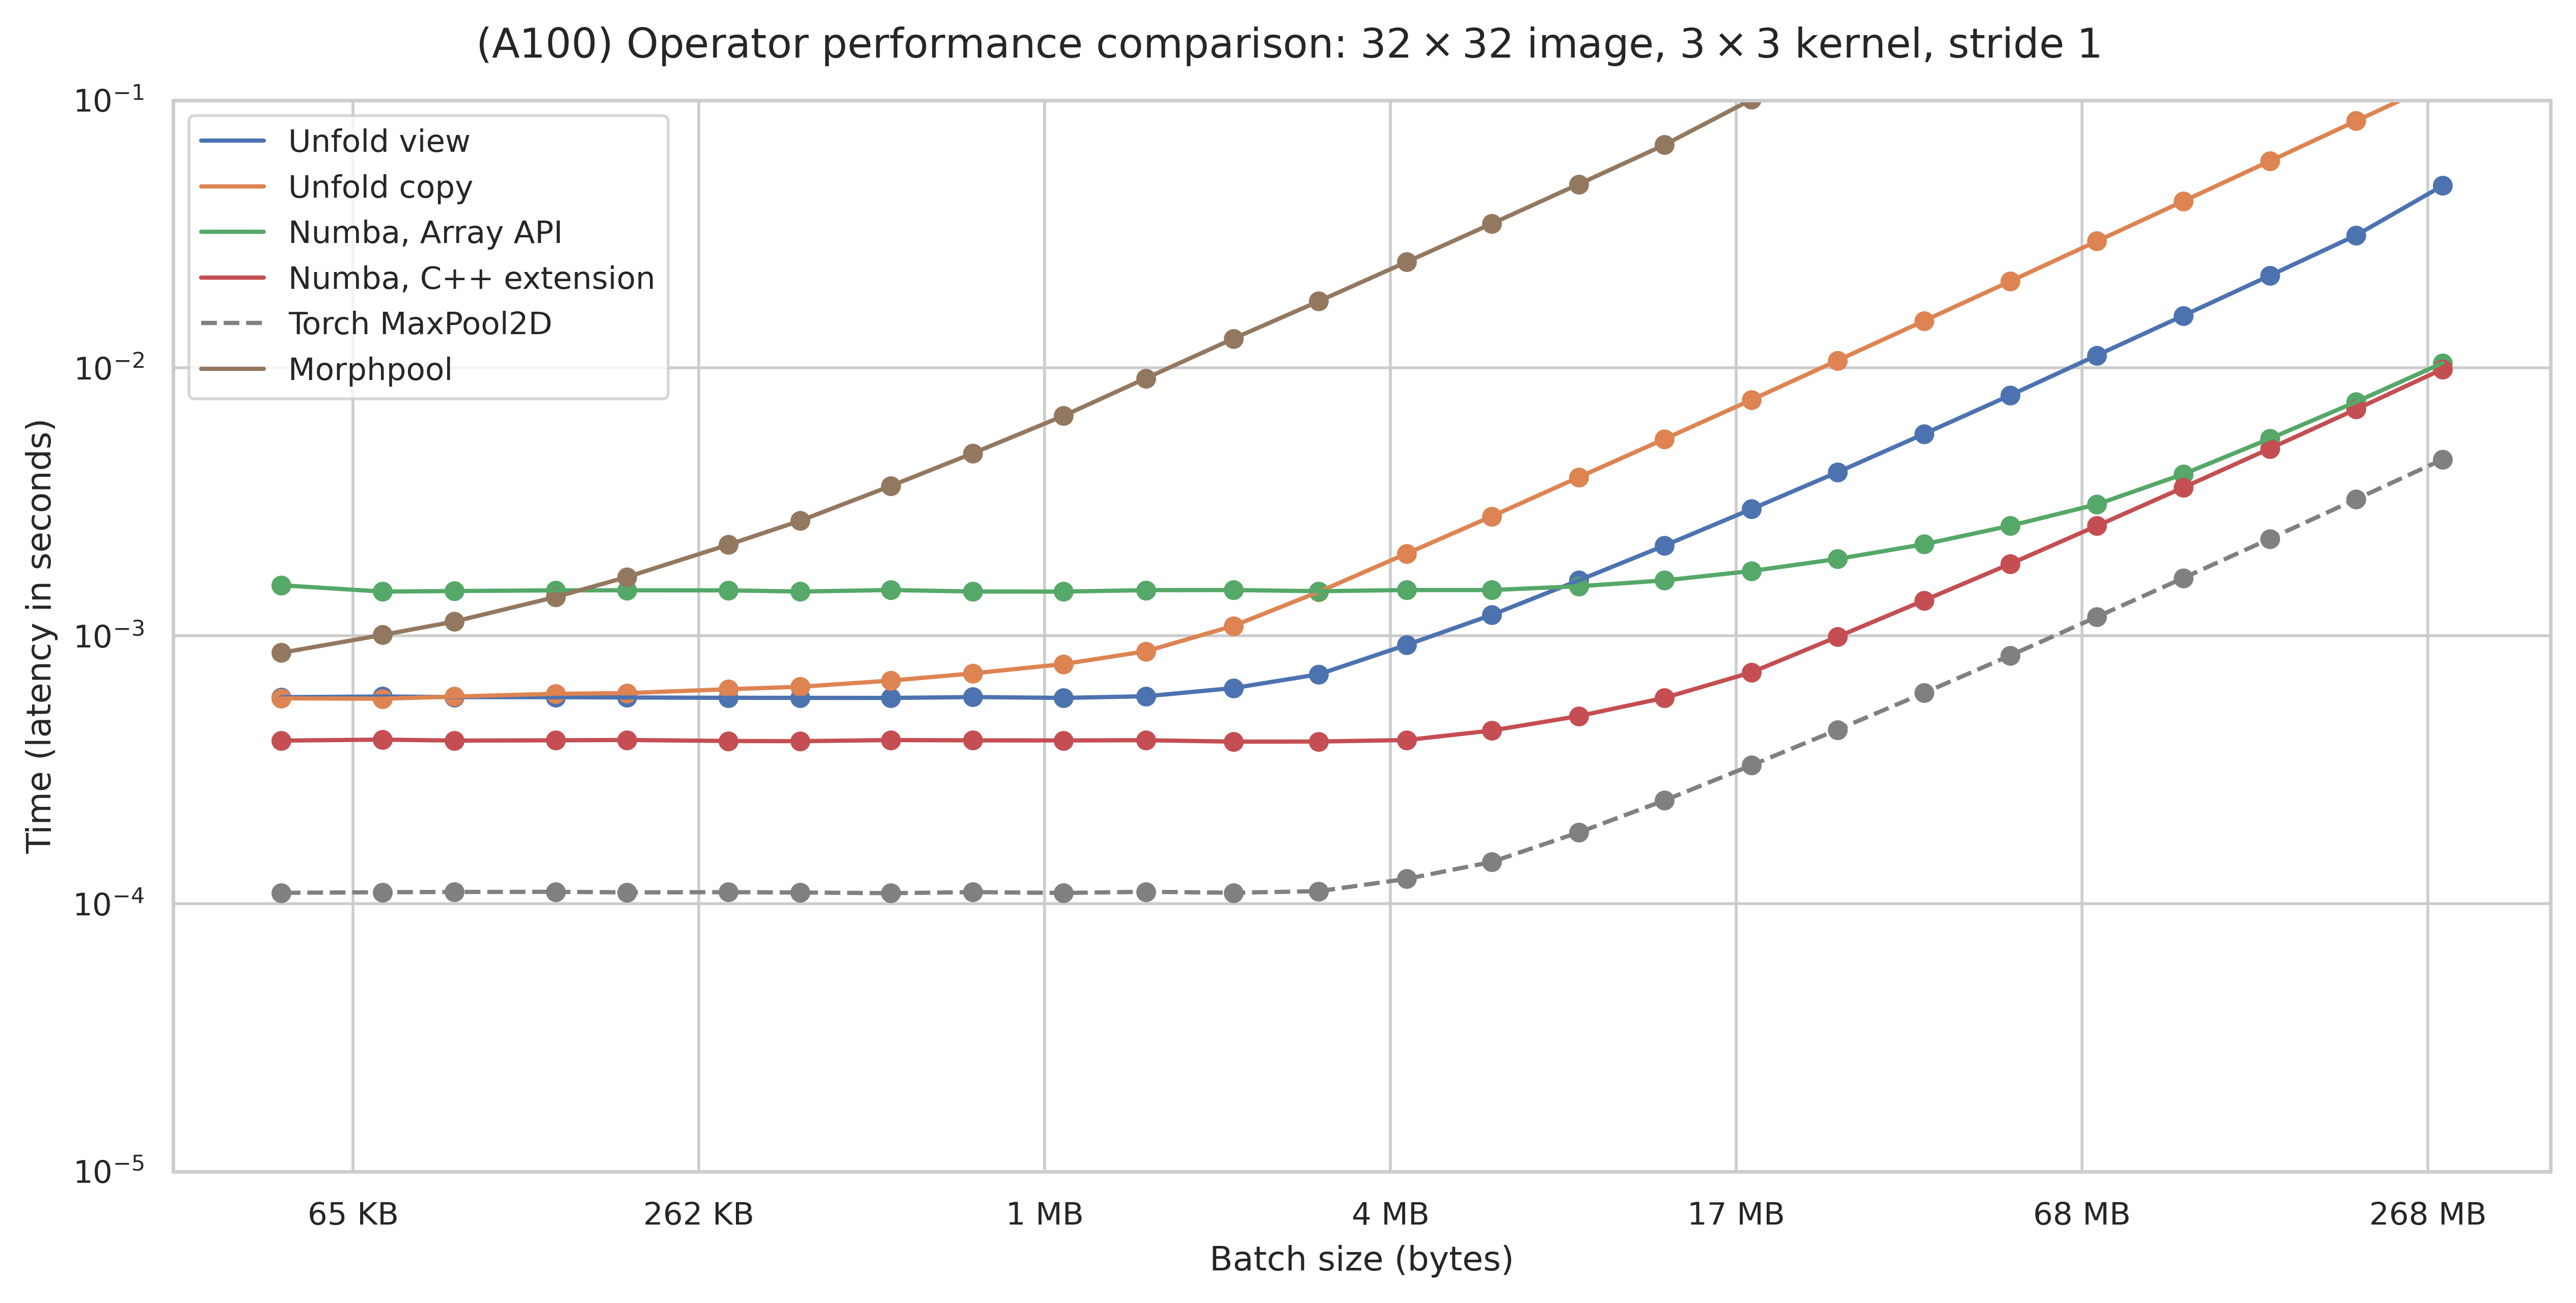

In [18]:
plot_timings_comparison(
    comp_s1[0],
    comp_s1[1],
    title=r"(A100) Operator performance comparison: $32\times32$ image, $3\times3$ kernel, stride 1",
)

/scratch-local/padema.12497542/ipykernel_3154880/283909195.py:50: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


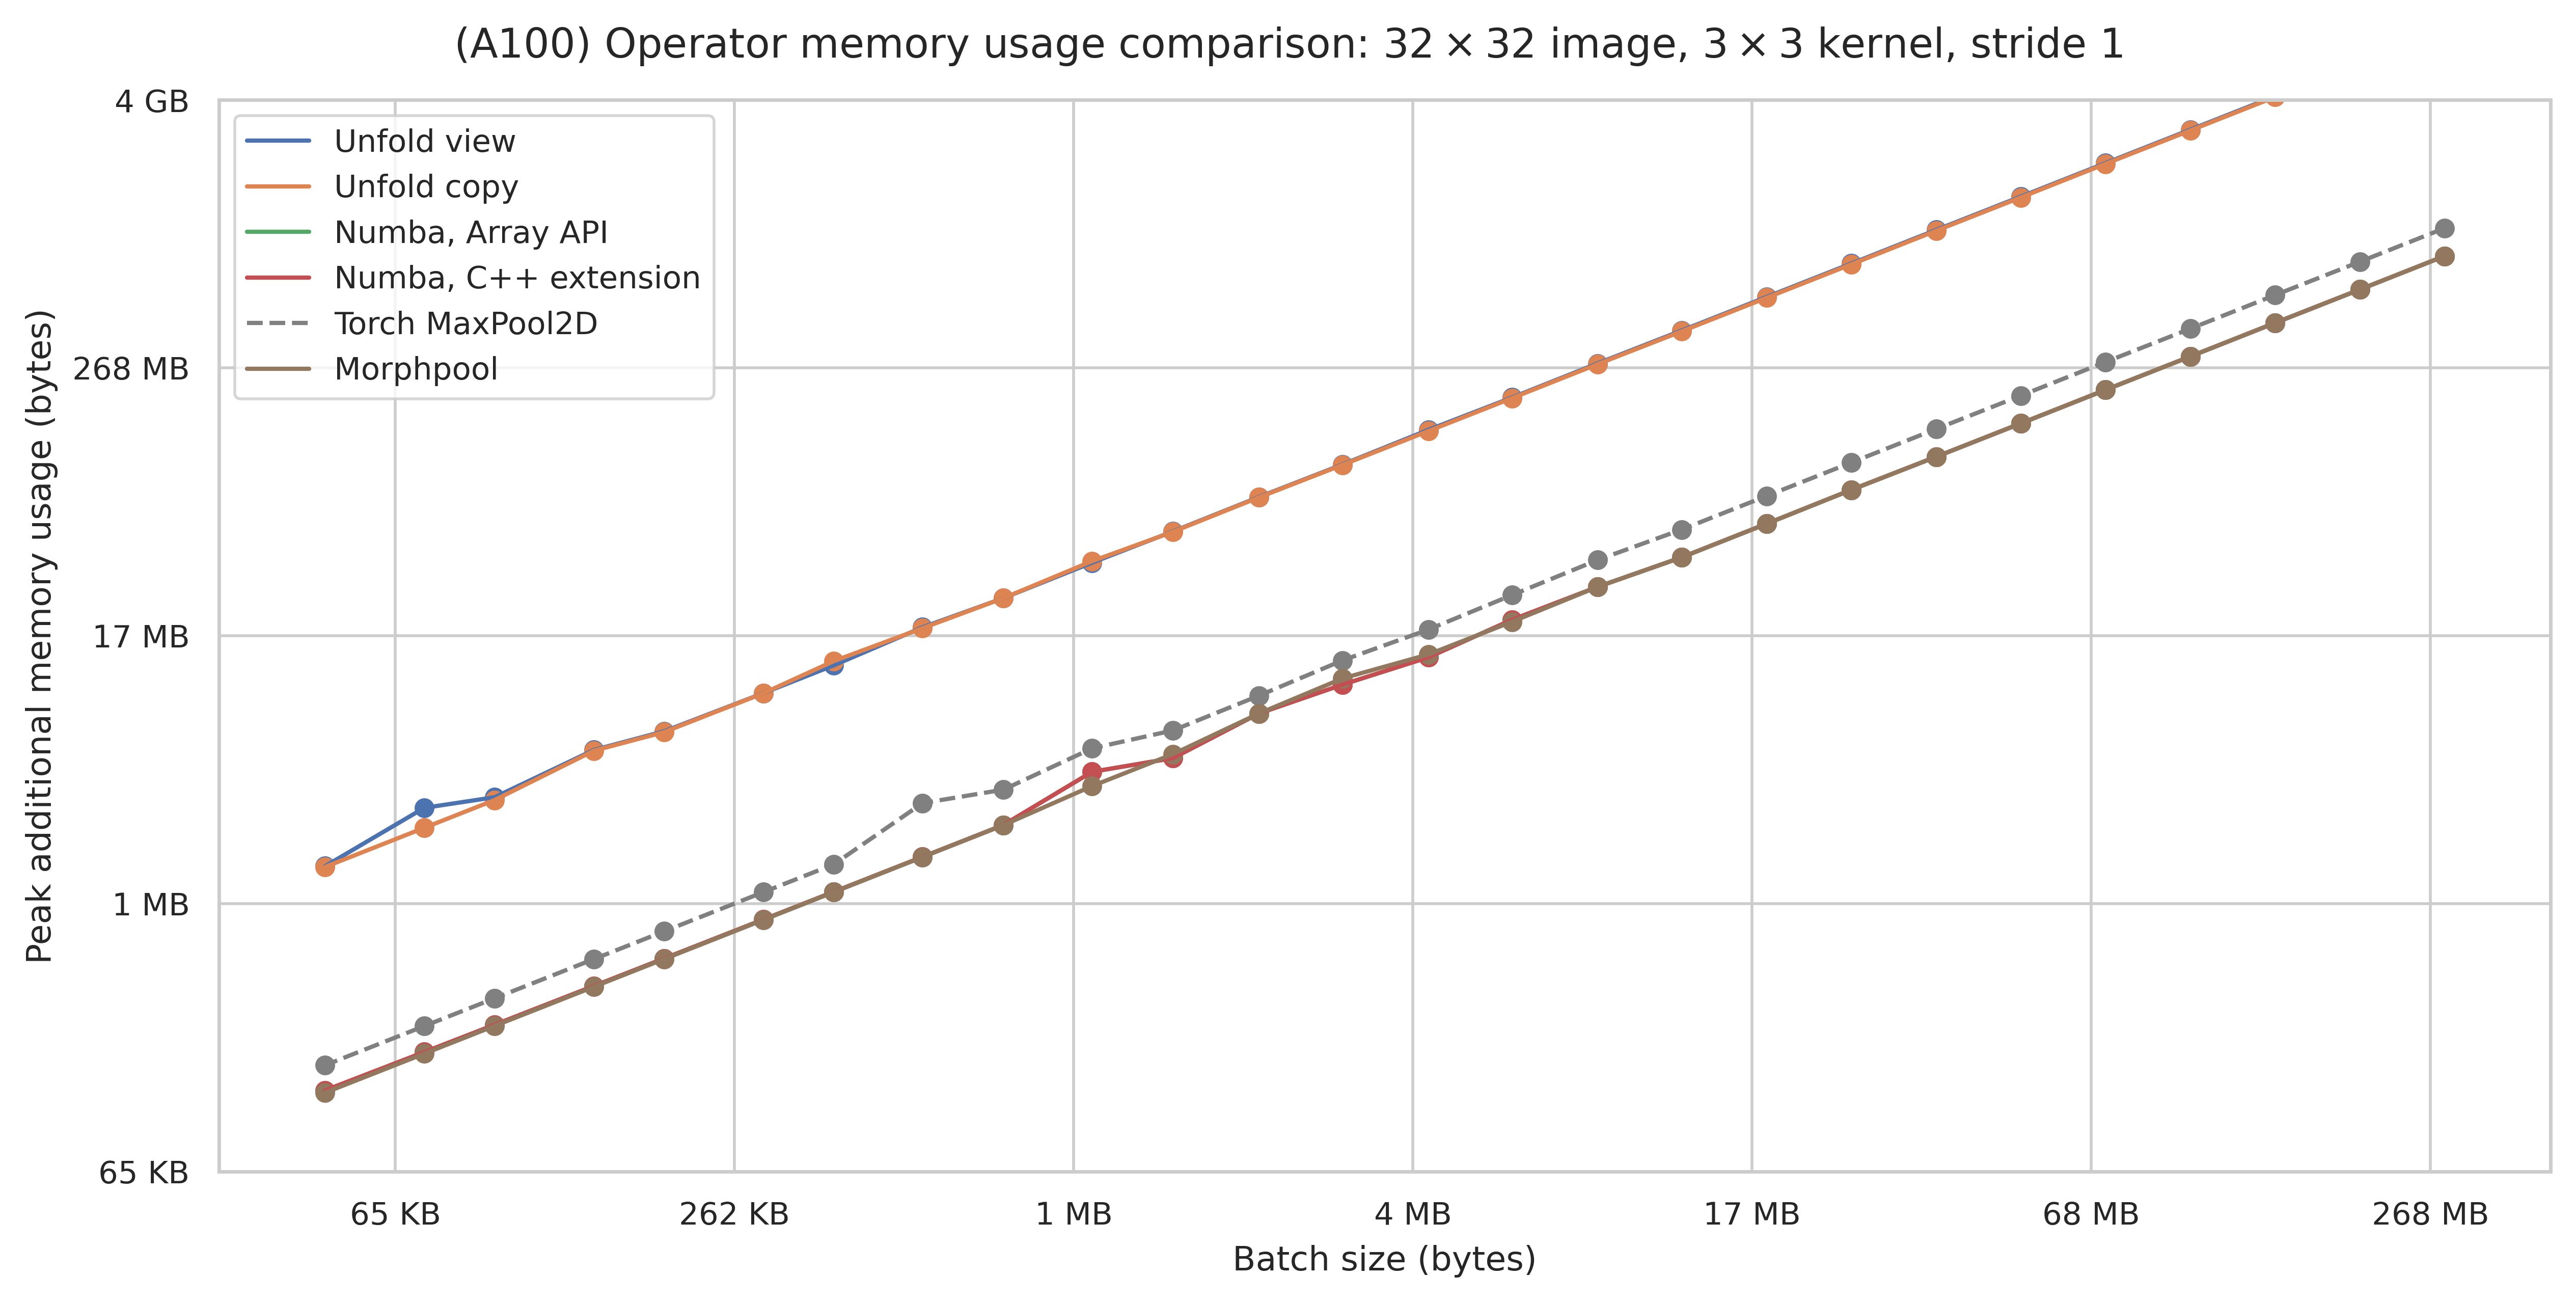

In [19]:
plot_timings_comparison(
    comp_s1[0],
    comp_s1[2],
    title=r"(A100) Operator memory usage comparison: $32\times32$ image, $3\times3$ kernel, stride 1",
    mem=True,
)

In [ ]:
comp_s3 = get_timings_comparison(stride=3)

/scratch-local/padema.12497542/ipykernel_3154880/283909195.py:50: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


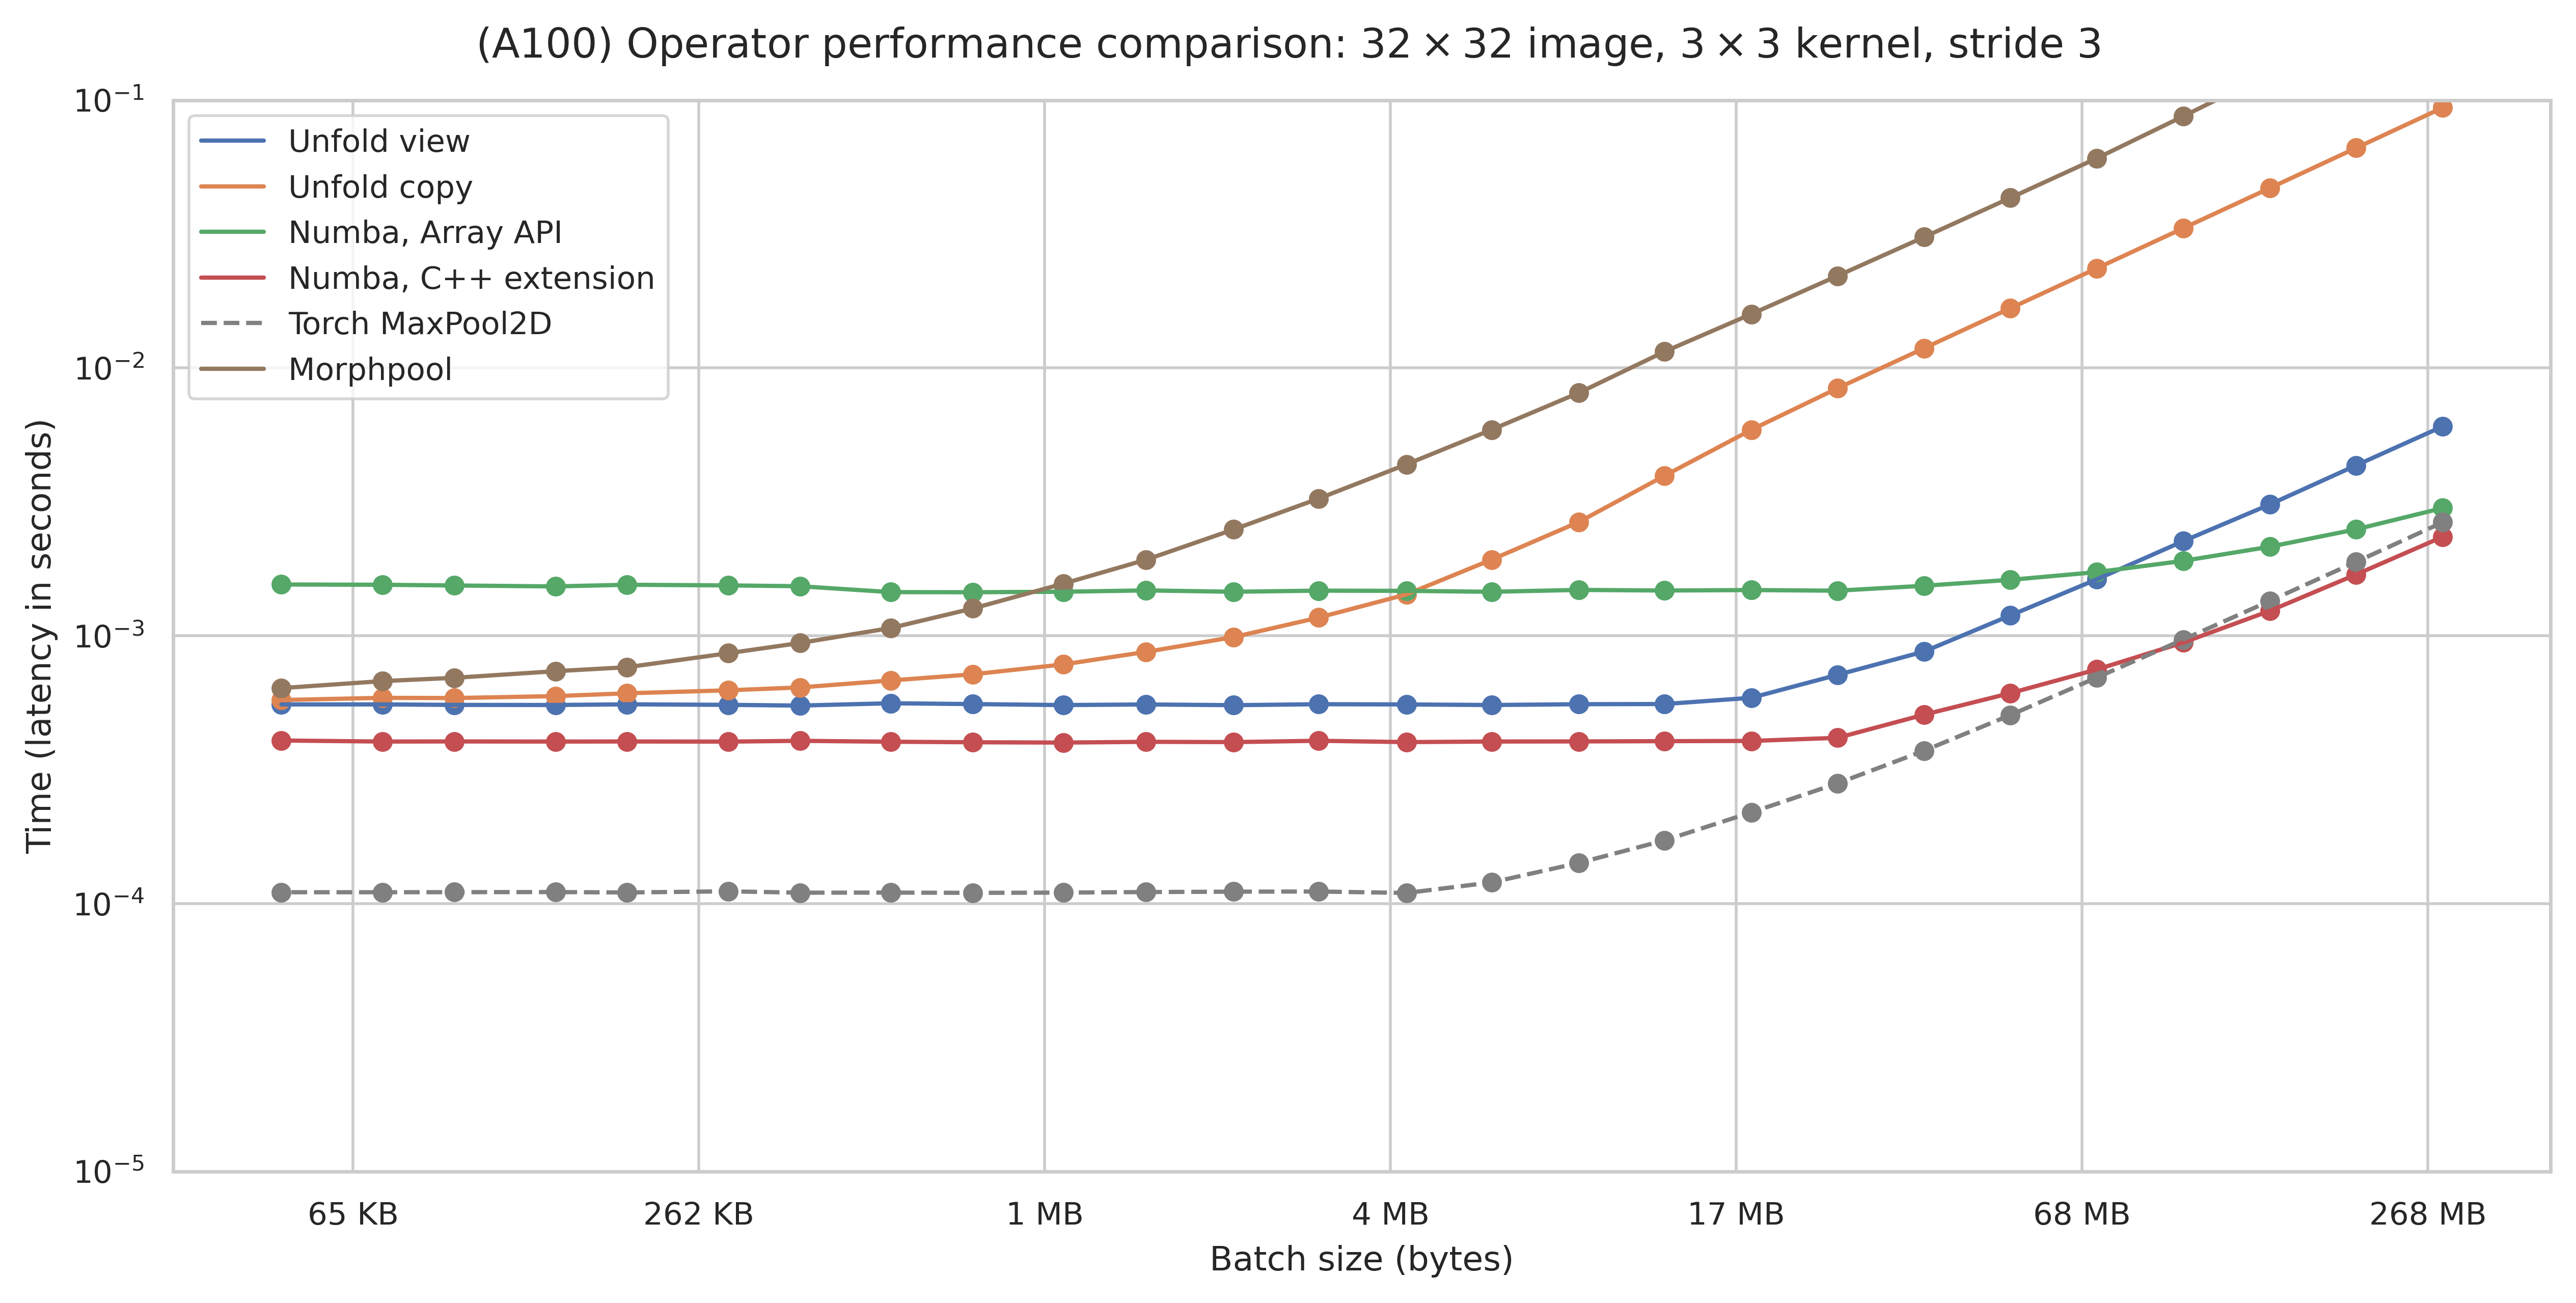

In [21]:
plot_timings_comparison(
    comp_s3[0],
    comp_s3[1],
    title=r"(A100) Operator performance comparison: $32\times32$ image, $3\times3$ kernel, stride 3",
)

/scratch-local/padema.12497542/ipykernel_3154880/283909195.py:50: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


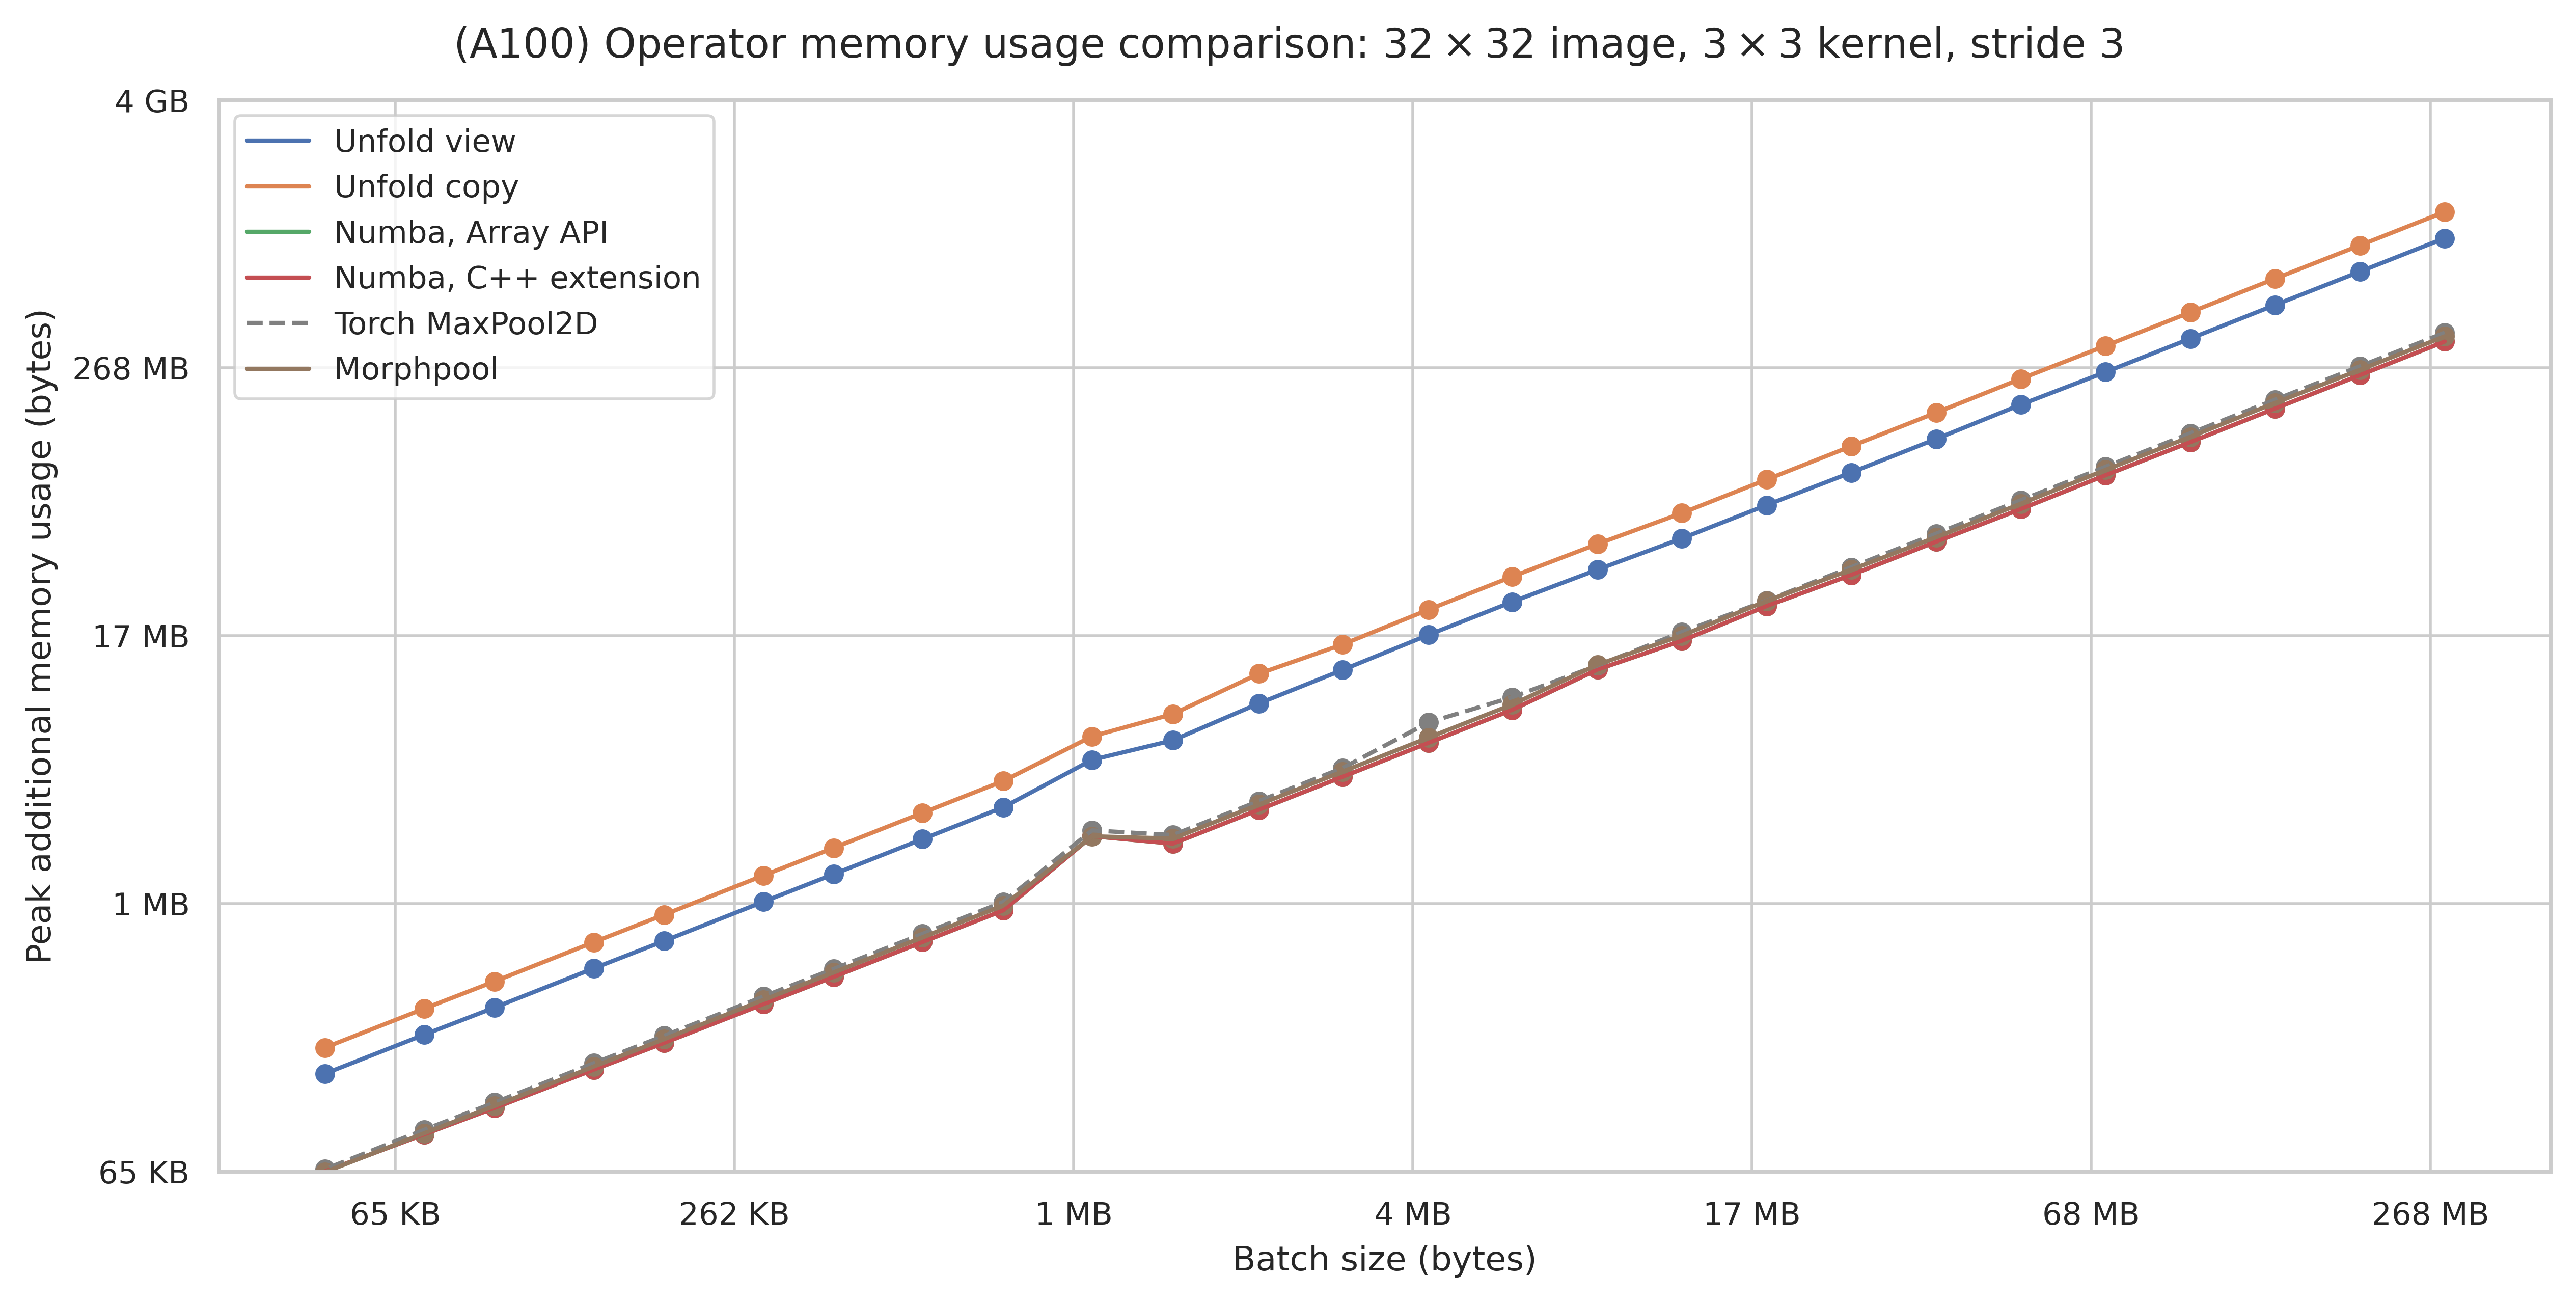

In [22]:
plot_timings_comparison(
    comp_s3[0],
    comp_s3[2],
    title=r"(A100) Operator memory usage comparison: $32\times32$ image, $3\times3$ kernel, stride 3",
    mem=True,
)

In [23]:
torch.manual_seed(0)
kernels_7x7 = torch.randn((6, 1, 7, 7), device="cuda")
kernels_7x7.shape

torch.Size([6, 1, 7, 7])

In [ ]:
comp_k7_s3 = get_timings_comparison(kernel=kernels_7x7, stride=3)

/scratch-local/padema.12497542/ipykernel_3154880/283909195.py:50: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


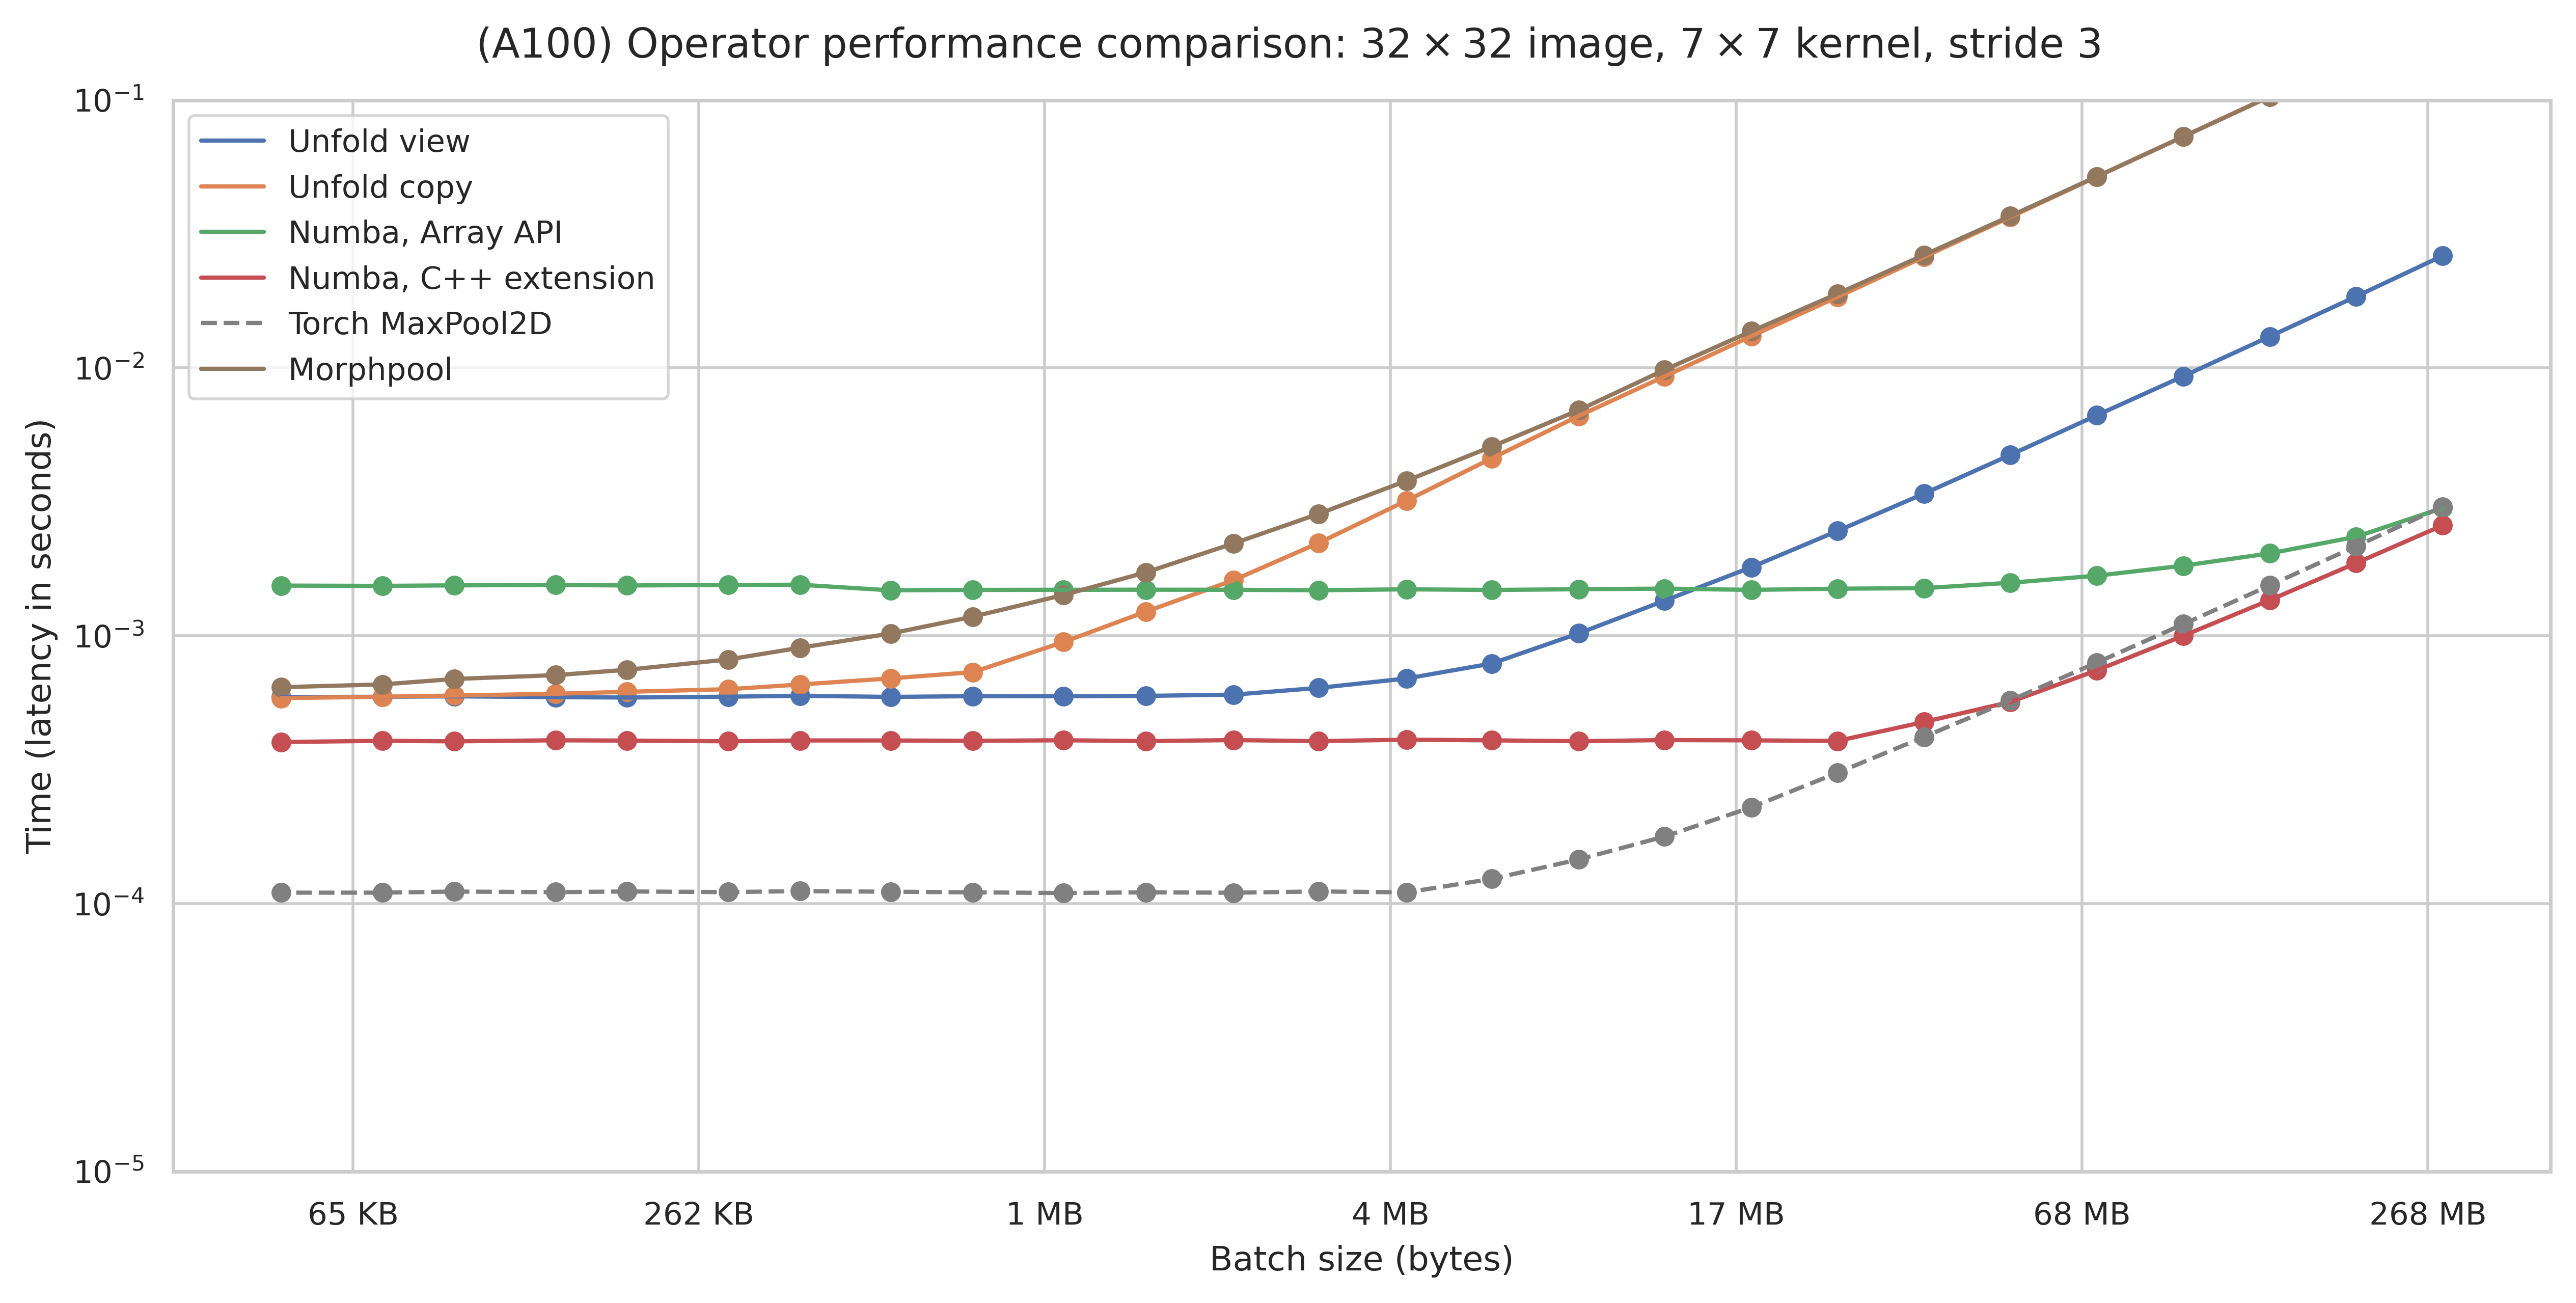

In [25]:
plot_timings_comparison(
    comp_k7_s3[0],
    comp_k7_s3[1],
    title=r"(A100) Operator performance comparison: $32\times32$ image, $7\times7$ kernel, stride 3",
)

/scratch-local/padema.12497542/ipykernel_3154880/283909195.py:50: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


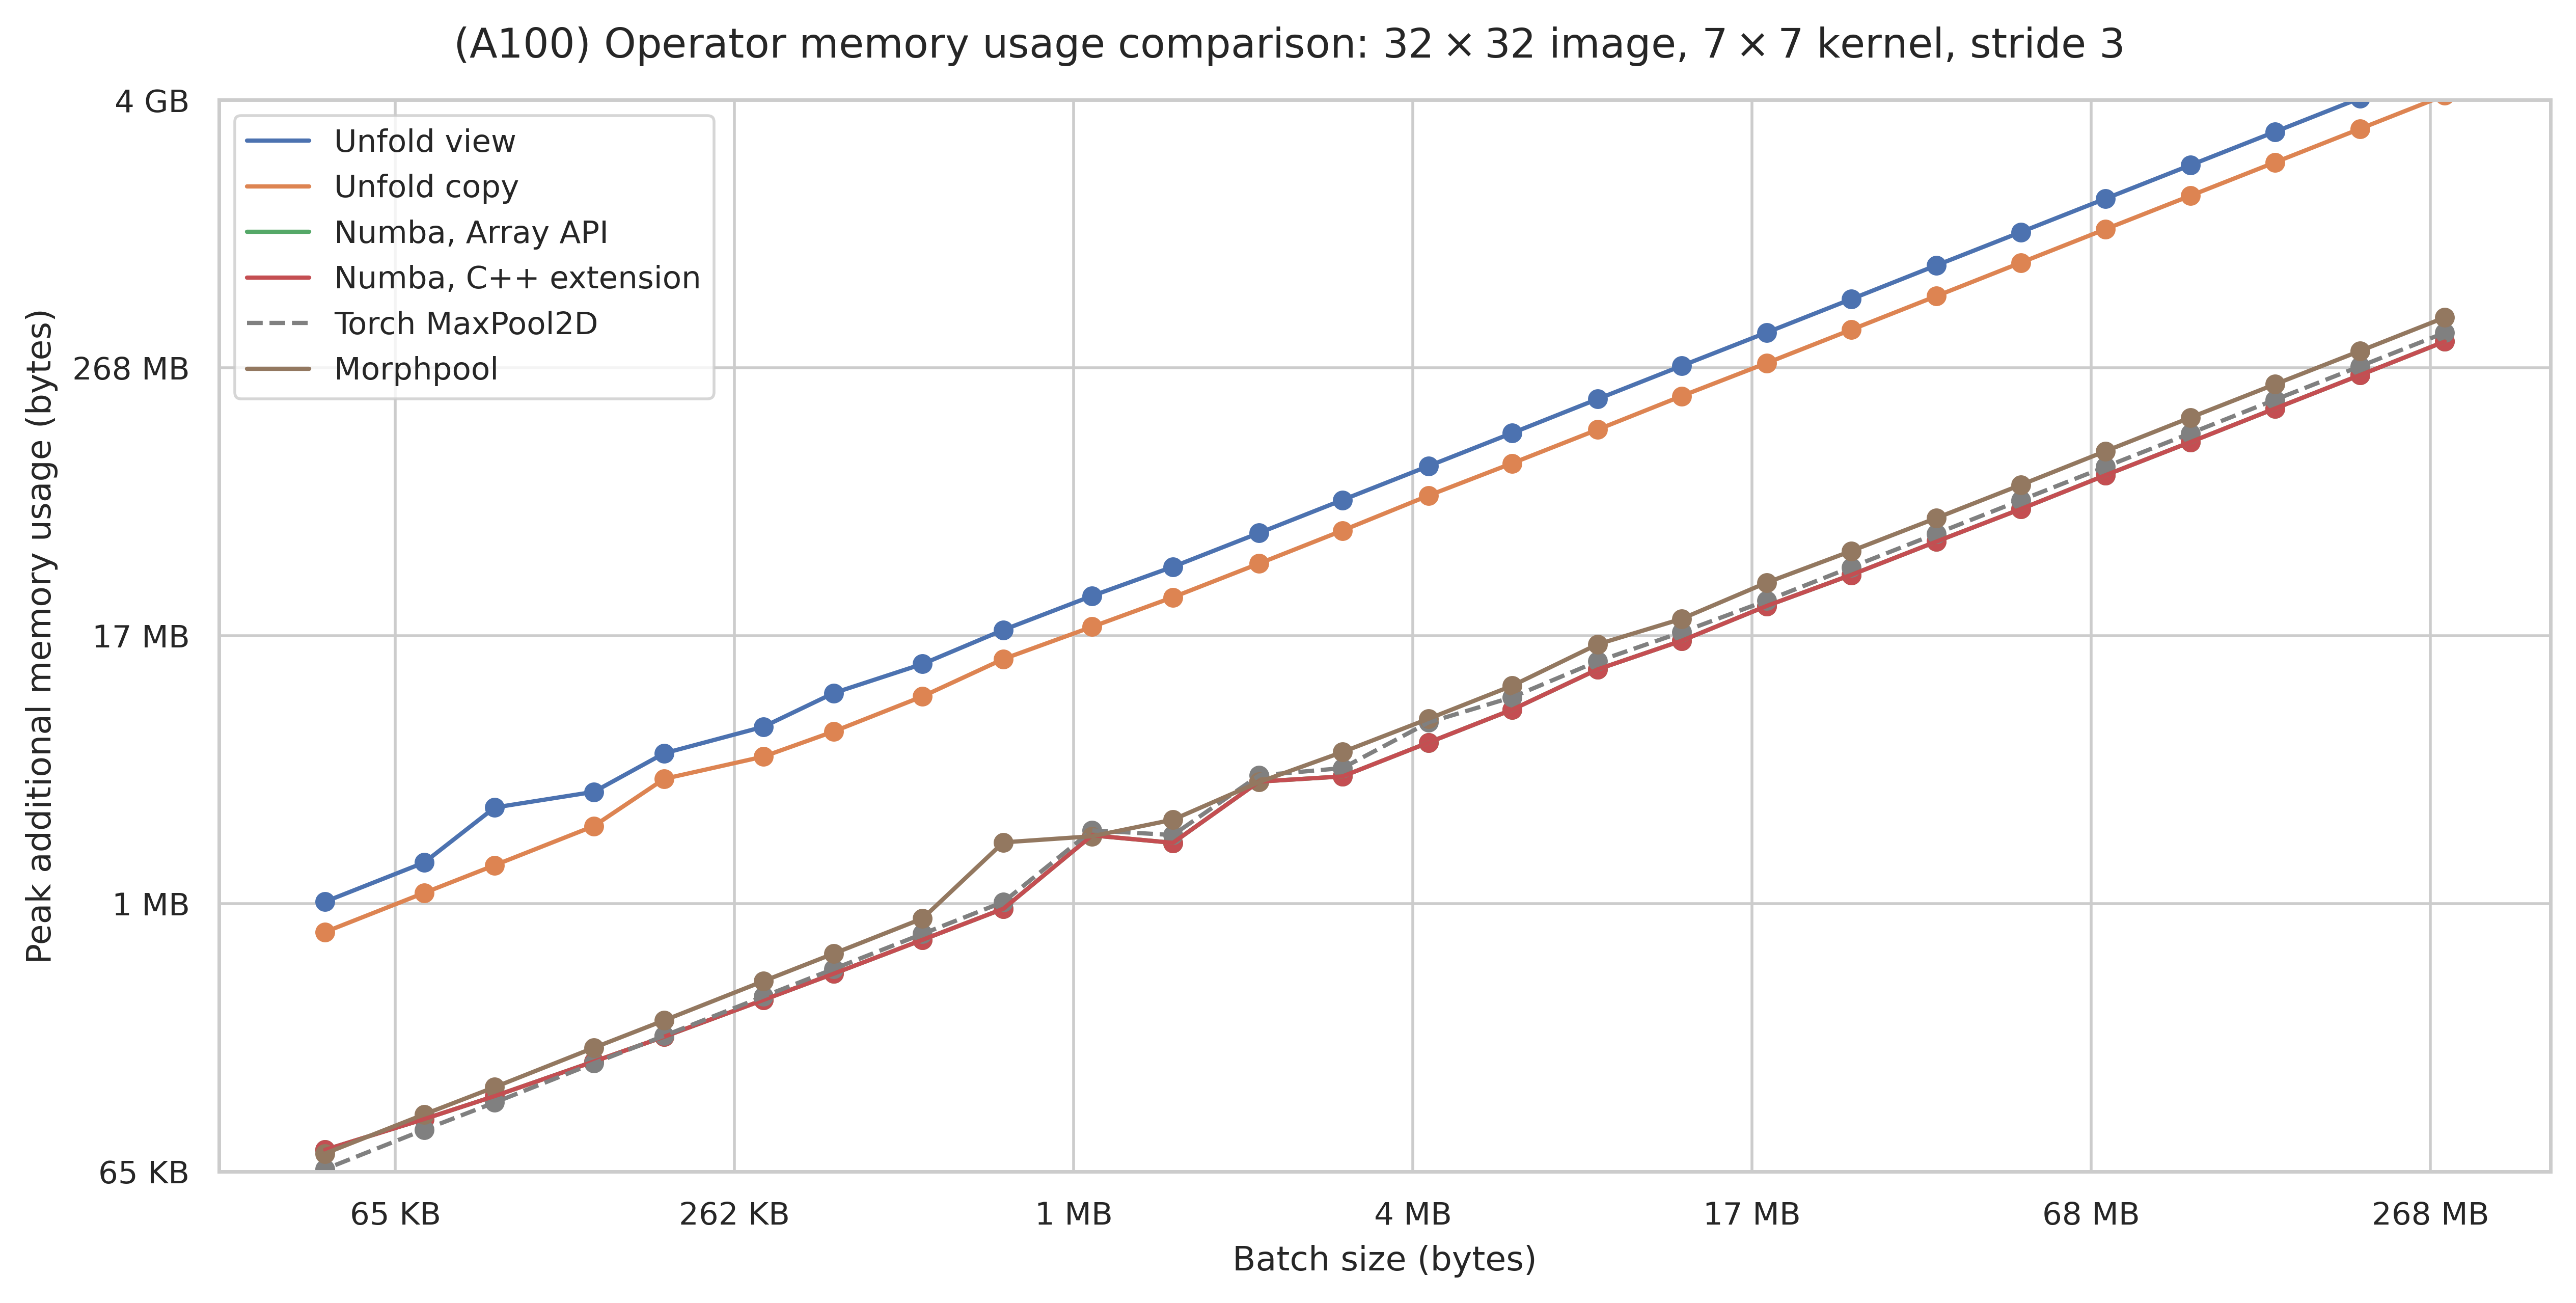

In [26]:
plot_timings_comparison(
    comp_k7_s3[0],
    comp_k7_s3[2],
    title=r"(A100) Operator memory usage comparison: $32\times32$ image, $7\times7$ kernel, stride 3",
    mem=True,
)

In [27]:
torch.manual_seed(0)
data_128x128 = torch.randn((6000, 6, 128, 128), device="cuda")
print(data_128x128.nbytes, "bytes")
data_128x128.shape

2359296000 bytes


torch.Size([6000, 6, 128, 128])

Due to technical difficulties, the last set of trials was not able to run on the A100 machine.